# Pixel Power Calculation with Atmospheric Transmission

This notebook demonstrates how to compute the power received from a pixel on Earth's surface,
taking into account thermal emission (using **Planck's law**) and attenuation due to the atmosphere.

We will go step by step:
1. Recall **Planck’s law**.
2. Integrate over wavelength bands.
3. Apply atmospheric transmission (two-way path).
4. Add a mock transmission spectrum to demonstrate the effect.

## Planck's Law
The spectral radiance of a blackbody is given by Planck’s law:

$$ B(\lambda, T) = \frac{2 h c^2}{\lambda^5} \cdot \frac{1}{\exp\left(\tfrac{h c}{\lambda k T}\right) - 1} $$

- $h$: Planck constant,
- $c$: speed of light,
- $k$: Boltzmann constant,
- $T$: temperature (K),
- $\lambda$: wavelength (m)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import h, c, k, pi

def planck_lambda(lmbd, T):
    """
    Planck's law: spectral radiance per wavelength [W / (m^3 sr)]
    lmbd: wavelength in m
    T: temperature in K
    """
    return (2 * h * c**2 / lmbd**5) * 1.0 / (np.exp((h * c) / (lmbd * k * T)) - 1)

## Integration over a Band
We often integrate Planck’s law over a wavelength band to obtain the **band radiance**:

$$ I(\lambda_1, \lambda_2, T) = \int_{\lambda_1}^{\lambda_2} B(\lambda, T) \, d\lambda $$

In [2]:
def integrate_band(T, lmbd_min, lmbd_max, n_samples=200):
    """
    Integrates Planck radiance over [lmbd_min, lmbd_max].
    Returns [W / (m^2 sr)].
    """
    wavelengths = np.linspace(lmbd_min, lmbd_max, n_samples)
    spectral = planck_lambda(wavelengths, T)
    return np.trapz(spectral, wavelengths)

## Atmospheric Transmission
When radiation passes through the atmosphere, it is attenuated.
If $\tau(\lambda)$ is the transmission, then for a two-way path (surface → satellite):

$$ S(n) = \tau(\lambda_n)^2 \int_{\lambda_n}^{\lambda_{n+1}} B(\lambda, T) d\lambda $$

In [3]:
def band_power_with_atmos(T, band_edges, tau_spectrum):
    """
    Calculates band-integrated power per band with atmospheric transmission.

    T: temperature [K]
    band_edges: array of wavelength edges [m]
    tau_spectrum: array of tau values for each band (len = len(band_edges)-1)

    Returns: array of band powers [W / (m^2 sr)]
    """
    results = []
    for i in range(len(band_edges)-1):
        l0, l1 = band_edges[i], band_edges[i+1]
        raw_band = integrate_band(T, l0, l1)
        attenuated = (tau_spectrum[i]**2) * raw_band
        results.append(attenuated)
    return np.array(results)

## Aperture Consideration
When calculating the radiative power from a pixel area $A_\mathrm{px}$ that reaches the detector through an optical system, the **aperture angle** $\theta_\mathrm{ap}$ must be considered. The aperture limits the solid angle over which radiation is collected.

The following function computes the pixel power $P_\mathrm{px}$ received by the detector, integrating Planck’s spectral radiance $S_\lambda(\lambda, T)$ over wavelength and the solid angle defined by the aperture:

$$
P_\mathrm{px} = A_\mathrm{px} \cdot \tau_\mathrm{opt} \cdot \alpha_\mathrm{det} \cdot \left[ \int_{\lambda_\mathrm{min}}^{\lambda_\mathrm{max}} B(\lambda, T)\; d\lambda \right] \cdot \pi \sin^2(\theta_\mathrm{ap})
$$

Das Integral über den Winkel $\theta$ ist hier nicht mehr explizit enthalten, weil die Integration über die Apertur (den Öffnungswinkel des Detektors) analytisch gelöst wurde. Für eine kreisförmige Apertur mit Halbwinkel $\theta_\mathrm{ap}$ und Lambert’scher Abstrahlung ergibt die Integration über den Raumwinkel den festen Faktor $\pi \sin^2(\theta_\mathrm{ap})$:

$$
\int_{\Omega_\mathrm{ap}} \cos\theta\, d\Omega = \pi \sin^2(\theta_\mathrm{ap})
$$

Dadurch wird das Winkelintegral durch diesen Ausdruck ersetzt und muss nicht mehr als separates Integral geschrieben werden. Das Ergebnis ist ein kompaktere Formel, in der die Geometrie der Apertur bereits berücksichtigt ist.

where  
- $A_\mathrm{px}$: pixel area  
- $\tau_\mathrm{opt}$: optical transmission  
- $\alpha_\mathrm{det}$: detector efficiency  
- $B(\lambda, T)$: Planck spectral radiance  
- $[\lambda_\mathrm{min}, \lambda_\mathrm{max}]$: wavelength band  
- $\theta_\mathrm{ap}$: aperture half-angle

**Explanation:**  
- The function `pixel_power_aperture` computes the power from a pixel area $A_\mathrm{px}$, integrating Planck’s law over a wavelength band $[\lambda_\mathrm{min}, \lambda_\mathrm{max}]$ and the solid angle defined by the aperture half-angle $\theta_\mathrm{ap}$.
- The factor $\pi \sin^2(\theta_\mathrm{ap})$ arises from integrating $\cos\theta \sin\theta$ over the aperture cone.
- The result is the total power reaching the detector, accounting for optical transmission ($\tau_\mathrm{opt}$) and detector efficiency ($\alpha_\mathrm{det}$).

This approach is essential for realistic detector modeling, as only radiation within the aperture is collected. The function can be used to analyze how changing the aperture or pixel area affects the detected signal.

---

$$\int_{\Omega_\mathrm{ap}} \cos\theta, d\Omega = \int_0^{2\pi} d\phi \int_0^{\theta_\mathrm{ap}} \cos\theta \sin\theta, d\theta = \pi \sin^2(\theta_\mathrm{ap})$$

Der ($\phi$)-Integral ((0) bis $(2\pi)$) und das (\theta)-Integral ((0) bis ($\theta_\mathrm{ap})$) sind analytisch zusammengefasst zu ($\pi \sin^2(\theta_\mathrm{ap})$).
Deshalb taucht der Faktor ($2\pi$) nicht separat auf – er steckt schon in der Formel.

Kurz:
Der Ausdruck ($\pi \sin^2(\theta_\mathrm{ap})$) ist das vollständige Ergebnis der Raumwinkelintegration für eine kreisförmige Apertur und Lambert’sche Quelle.



In [4]:
def pixel_power_aperture(T, lmbd_min, lmbd_max, theta_ap, A_px, tau_opt=0.9, alpha_det=0.9, n_samples=400):
    """
    Calculates pixel power received through an aperture.
    T: temperature [K]
    lmbd_min, lmbd_max: wavelength bounds [m]
    theta_ap: aperture half-angle [rad]
    A_px: pixel area [m^2]
    tau_opt: optical transmission
    alpha_det: detector efficiency
    """
    # Integrate Planck over wavelength
    wavelengths = np.linspace(lmbd_min, lmbd_max, n_samples)
    spectral = planck_lambda(wavelengths, T)
    I_band = np.trapz(spectral, wavelengths)  # [W / (m^2 sr)]

    # Integrate over solid angle defined by aperture
    Omega_ap = 2 * pi * (1 - np.cos(theta_ap))  # [sr]
    # For Lambertian source, radiance is weighted by cos(theta)
    solid_angle_factor = pi * (np.sin(theta_ap))**2  # ∫cosθ sinθ dθ dΦ over aperture

    # Total power
    P_px = A_px * tau_opt * alpha_det * I_band * solid_angle_factor
    return P_px

In [5]:
pixel_power_aperture(T=300,
                     lmbd_min=1e-6, lmbd_max=2e-6,
                     theta_ap=np.radians(5), A_px=1e-4,
                     tau_opt=0.9, alpha_det=0.9)
# Example usage of the function
# This will calculate the pixel power received through an aperture
# at a temperature of 300 K, with specified wavelength bounds, aperture angle,
# pixel area, optical transmission, and detector efficiency.    

C:\Users\azmib\AppData\Local\Temp\ipykernel_21000\51797890.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_band = np.trapz(spectral, wavelengths)  # [W / (m^2 sr)]


np.float64(2.6264533410214528e-11)

## Gesamte Pixel-Leistung: Emission, Albedo und Glint

Die vollständige Formel für die spektrale Leistung eines Pixels, die von einer Fläche auf der Erdoberfläche stammt und durch die Optik auf den Detektor gelangt, setzt sich aus drei Komponenten zusammen:

1. **Thermische Emission des Bodens** (`P_Boden`)
2. **Reflektierte Sonnenstrahlung (Albedo)** (`P_Albedo`)
3. **Glint-Anteil** (`P_Glint`)

Jede Komponente wird über die Wellenlängenbänder integriert und mit der jeweiligen atmosphärischen Transmission $\tau_n$ gewichtet. Die Gesamtsumme ergibt die auf dem Detektor ankommende Leistung:

$$
P_\mathrm{px} = P_\mathrm{Boden} + P_\mathrm{Albedo} + P_\mathrm{Glint}
$$

### Allgemeine Formel für ein Band $n$:

$$
P_\mathrm{Band,\,total} = A_\mathrm{px} \cdot \tau_\mathrm{opt} \cdot \alpha_\mathrm{det} \cdot \left[ \sum_{n=1}^{N} \tau_n^2 \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T)\, d\lambda \cdot \Omega_\mathrm{ap} \right]
$$

mit  
- $A_\mathrm{px}$: Pixel-Fläche  
- $\tau_\mathrm{opt}$: optische Transmission  
- $\alpha_\mathrm{det}$: Detektor-Effizienz  
- $\tau_n$: atmosphärische Transmission im Band $n$  
- $S_\lambda(\lambda, T)$: spektrale Strahldichte (Planck oder Sonne)  
- $\Omega_\mathrm{ap}$: Apertur-Solidwinkel (z.B. $\pi \sin^2(\theta_\mathrm{ap})$)

### Komponenten:

- **Boden-Emission:**  
    $P_\mathrm{Boden} = \sum_{n=1}^{N} \pi \cdot A_\mathrm{px} \cdot \epsilon_\mathrm{ground} \cdot \tau_n^2 \cdot \int_{\lambda_n}^{\lambda_{n+1}} B_\mathrm{ground}(\lambda, T_\mathrm{ground})\, d\lambda$

- **Albedo:**  
    $P_\mathrm{Albedo} = \sum_{n=1}^{N} \pi \cdot A_\mathrm{px} \cdot \rho_\mathrm{Albedo}\cdot \tau_n^2 \cdot \rho_\mathrm{geom., sun} \cdot \int_{\lambda_n}^{\lambda_{n+1}} B_\mathrm{sun}(\lambda, T_\mathrm{sun})\, d\lambda$

- **Glint:**  
    $P_\mathrm{Glint} = \sum_{n=1}^{N} \pi \cdot A_\mathrm{px} \cdot \delta_\mathrm{Glint} \cdot \rho_\mathrm{Water} \cdot \tau_n^2 \cdot \int_{\lambda_n}^{\lambda_{n+1}} B_\mathrm{sun}(\lambda, T_\mathrm{sun})\, d\lambda$


**Hinweis:**  
- $\rho_\mathrm{Glint}$ ist das Verhältnis von Wasser- zu Nicht-Wasser-Fläche am Pixel (z.B. Anteil Wasserfläche).
- Der geometrische Faktor für die solare Einstrahlung ist $\rho_\mathrm{geom,\,sun} = r_\mathrm{sun}^2 / d_\mathrm{SE}^2$, wobei $r_\mathrm{sun}$ der Sonnenradius und $d_\mathrm{SE}$ der Abstand Sonne–Erde ist.


### Zusammenfassung

Die **Gesamtleistung pro Pixel** ist die Summe aller Beiträge, jeweils integriert über die Bänder und gewichtet mit der Transmission und den geometrischen Faktoren:

$$
P_\mathrm{px,\,total} = P_\mathrm{Boden} + P_\mathrm{Albedo} + P_\mathrm{Glint}
$$

Jeder Term kann mit den vorhandenen Funktionen im Notebook berechnet werden, indem die jeweiligen Faktoren (Emissivität, Albedo, Glint) und die Transmission pro Band eingesetzt werden.

In [6]:
def generic_band_power(band_edges: np.array, tau_band, area: float, spectral_func, theta_ap: float = np.deg2rad(12), spectral_args=(),
                       factor=1.0, n_samples=400, single_transmission=False):
    """
    Generic band-integrated power calculator.

    band_edges: array of wavelength edges [m]
    tau_band: array of transmission per band (len = len(band_edges)-1)
    area: pixel area [m^2]
    spectral_func: function(lmbd, *spectral_args) -> spectral radiance [W/(m^3 sr)]
    spectral_args: tuple of extra arguments for spectral_func (e.g. temperature)
    factor: constant prefactor (e.g. pi * emissivity, pi * albedo * geom, etc.)
    n_samples: integration samples per band

    Returns: array of powers per band [W], total power [W]
    """
    powers = []
    for i in range(len(band_edges)-1):
        l0, l1 = band_edges[i], band_edges[i+1]
        wavelengths = np.linspace(l0, l1, n_samples)
        spectral = spectral_func(wavelengths, *spectral_args)
        I_band = np.trapz(spectral, wavelengths)  # [W/(m^2 sr)]
        # debug: print(f"Band {i}: Wavelengths {l0:.2e} to {l1:.2e}, Integrated Radiance: {I_band:.2e} W/(m^2 sr)")
        if single_transmission:
            # If single transmission value is provided, apply it directly
            I_band_atm = I_band * tau_band[i]
        else:
            I_band_atm = I_band * tau_band[i]**2
        # debug: print(f"Band {i}: Transmission: {tau_band[i]:.2e}, Adjusted Radiance: {I_band_atm:.2e} W/(m^2 sr)")
        solid_angle_factor = pi * (np.sin(theta_ap))**2
        P_band = factor * area * I_band_atm * solid_angle_factor
        powers.append(P_band)
    powers = np.array(powers)
    return powers, powers.sum()

## Mock Atmospheric Spectrum
For demonstration, we create a synthetic atmospheric transmission spectrum with an absorption
dip around 4.3 µm (CO₂ band).

In [7]:
# --- Mock spectrum setup ---
T_ground = 300.0
lmbd_min, lmbd_max = 3e-6, 5e-6

# Divide band into sub-bands (e.g. 10 channels)
n_bands = 10
band_edges = np.linspace(lmbd_min, lmbd_max, n_bands+1)

# Mock transmission: Gaussian dip around 4.3 µm (CO2 absorption)
band_centers = 0.5*(band_edges[:-1] + band_edges[1:])
tau_mock = 0.8 - 0.5*np.exp(-((band_centers - 4.3e-6)**2)/(0.1e-6)**2)

# Compute band powers
# Parameter
delta_glint = 0.00 # Glint factor (assumed for simplicity)
T_sun = 5777.0
rho_albedo = 0.03
tau_opt = 0.5
alpha_det = 0.8
D = 0.06         # [m]
d = 600e3        # [m]
theta_ap = 0.5 * D / d  # [rad]
GSD = 200 # [m]
A_px = GSD**2         # Pixel area on earths [m^2]

# Boden-Emission
P_ground_band, P_ground_total = generic_band_power(
    band_edges, tau_mock, A_px, theta_ap=theta_ap,
    spectral_func=planck_lambda, spectral_args=(T_ground,),
    factor=pi * 1.0,
    single_transmission=True  # Use single transmission value for ground emission
)

# Albedo (reflektierte Solarleistung)
geom = (6.9634e8**2) / (1.5e11**2)
P_albedo_band, P_albedo_total = generic_band_power(
    band_edges, tau_mock, A_px, theta_ap=theta_ap,
    spectral_func=planck_lambda, spectral_args=(T_sun,),
    factor=pi * rho_albedo * geom
)

# Glint (vereinfachte Annahme: wie Albedo, aber mit delta_glint als Faktor)
P_glint_band, P_glint_total = generic_band_power(
    band_edges, tau_mock, A_px, theta_ap=theta_ap,
    spectral_func=planck_lambda, spectral_args=(T_sun,),
    factor=pi * delta_glint * geom
)

# Optik- und Sensorfaktor anwenden
P_ground_band *= tau_opt * alpha_det
P_albedo_band *= tau_opt * alpha_det
P_glint_band *= tau_opt * alpha_det

# Gesamtsumme
P_total_band = P_ground_band + P_albedo_band + P_glint_band
P_total = P_total_band.sum()


C:\Users\azmib\AppData\Local\Temp\ipykernel_21000\1394235320.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_band = np.trapz(spectral, wavelengths)  # [W/(m^2 sr)]


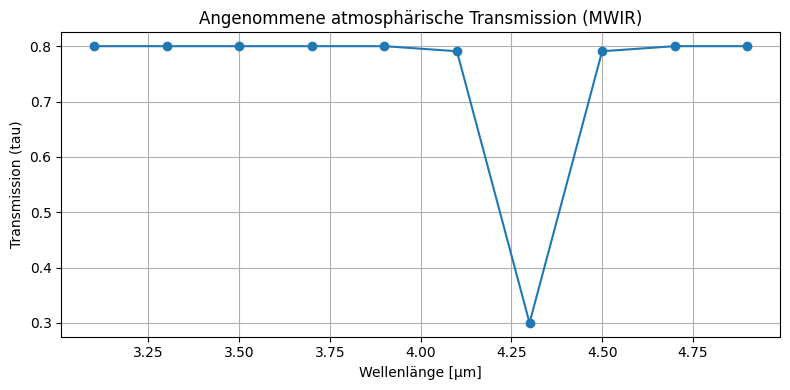

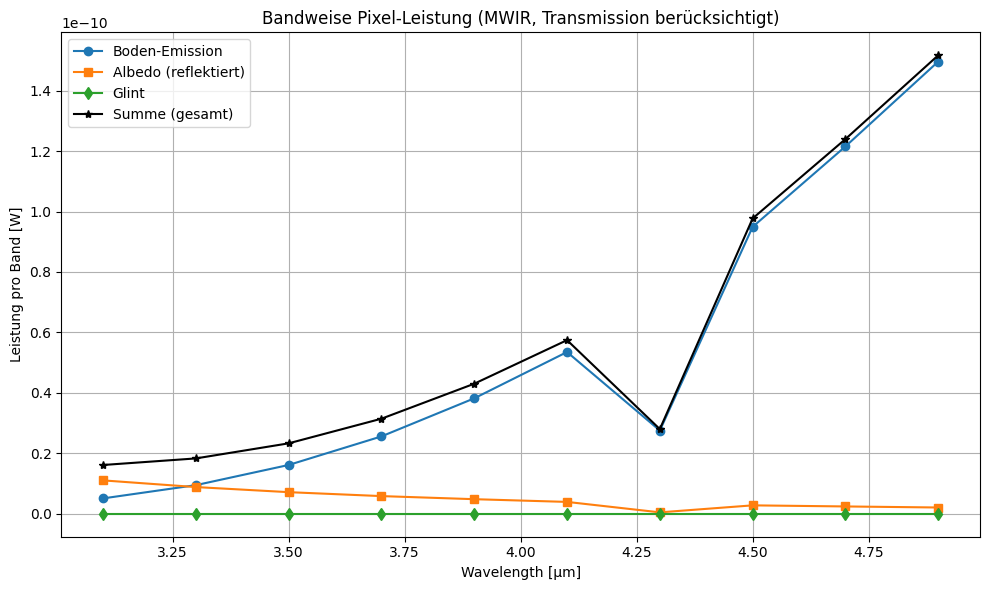

In [8]:
plt.figure(figsize=(8,4))
plt.plot(band_centers * 1e6, tau_mock, 'o-', color='tab:blue')
plt.xlabel('Wellenlänge [µm]')
plt.ylabel('Transmission (tau)')
plt.title('Angenommene atmosphärische Transmission (MWIR)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot der bandweisen Leistungen
plt.figure(figsize=(10,6))
plt.plot(band_centers * 1e6, P_ground_band, 'o-', label='Boden-Emission')
plt.plot(band_centers * 1e6, P_albedo_band, 's-', label='Albedo (reflektiert)')
plt.plot(band_centers * 1e6, P_glint_band, 'd-', label='Glint')
plt.plot(band_centers * 1e6, P_total_band, 'k*-', label='Summe (gesamt)')

plt.xlabel('Wavelength [µm]')
plt.ylabel('Leistung pro Band [W]')
plt.title('Bandweise Pixel-Leistung (MWIR, Transmission berücksichtigt)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Thermische Leistung und gemischte Pixel: 
Die Funktion liefert die Leistungen pro Band und die Gesamtsumme für Boden, Feuer und das gemischte Pixel.

$$
P_\text{mix,\,Band} = (1 - \delta_\text{fire}) \cdot P_\text{ground,\,Band} + \delta_\text{fire} \cdot P_\text{fire,\,Band}
$$

Diese Funktion berechnet die **Gesamtleistung eines Pixels**, das aus einem Anteil Boden und einem Anteil Feuer besteht:

- Die Leistungen für Boden und Feuer werden separat berechnet (jeweils mit eigener Temperatur und Emissivität).
- Die Mischung erfolgt linear nach Anteil $\delta_\text{fire}$:

Für die Berechnung der einzelnen Leistungen wird folgende Funktion von oben herangezogen:

$$
P_\mathrm{Band,\,total} = A_\mathrm{px} \cdot \tau_\mathrm{opt} \cdot \alpha_\mathrm{det} \cdot \left[ \sum_{n=1}^{N} \tau_n^2 \cdot \int_{\lambda_n}^{\lambda_{n+1}} S_\lambda(\lambda, T)\, d\lambda \cdot \Omega_\mathrm{ap} \right]
$$

---
Die **totale Pixel-Leistung** ergibt sich jetzt als Summe aus gemischter Boden/Feuer-Leistung, Albedo und Glint:

$$
P_\text{px,\,total} = P_\text{mix,\,Band} + P_\text{Albedo,\,Band} + P_\text{Glint,\,Band}
$$

Die Gesamtsumme über alle Bänder ist:

$$
P_\text{px,\,total} = \sum_{n=1}^{N} \left[ P_\text{mix,\,Band}(n) + P_\text{Albedo,\,Band}(n) + P_\text{Glint,\,Band}(n) \right]
$$

**In Python:**
**Zusammengefasst:**  
Mit diesen Funktionen kann man die detektierte thermische Leistung für beliebige Szenen (z. B. Feuer auf Boden) und beliebige atmosphärische Bedingungen bandweise berechnen. Sie sind die Grundlage für die weitere Analyse von Detektorsignalen und Sensitivität.'

In [9]:
def mixed_pixel_power_ground_fire(T_ground, T_fire, delta_fire, band_edges, tau_band, area, tau_opt=0.9, alpha_det=0.8, rho_albedo=0.03, delta_glint=0.01, geom=geom):
    """
    Berechnet die Gesamtleistung eines Pixels mit Boden/Feuer-Mischung, Albedo und Glint.
    delta_fire: Anteil Feuer im Pixel (z.B. 0.1 für 10%)
    area: Pixel-Fläche [m^2]
    """
    # Boden-Emission
    P_ground_band, P_ground_total = generic_band_power(
        band_edges, tau_band, area,
        spectral_func=planck_lambda, spectral_args=(T_ground,),
        factor=1.0
    )
    # Feuer-Emission
    P_fire_band, P_fire_total = generic_band_power(
        band_edges, tau_band, area,
        spectral_func=planck_lambda, spectral_args=(T_fire,),
        factor=1.0
    )
    # Gemischte Pixel-Leistung
    P_mix_band = (1 - delta_fire) * P_ground_band + delta_fire * P_fire_band
    P_mix_band *= tau_opt * alpha_det

    # Albedo
    P_albedo_band, _ = generic_band_power(
        band_edges, tau_band, area,
        spectral_func=planck_lambda, spectral_args=(T_sun,),
        factor=rho_albedo * geom
    )
    P_albedo_band *= tau_opt * alpha_det

    # Glint
    P_glint_band, _ = generic_band_power(
        band_edges, tau_band, area,
        spectral_func=planck_lambda, spectral_args=(T_sun,),
        factor=pi * delta_glint * geom
    )
    P_glint_band *= tau_opt * alpha_det

    # Gesamtsumme pro Band und total
    P_total_band = P_mix_band + P_albedo_band + P_glint_band
    P_total = P_total_band.sum()

    return {
        "P_fire_band": P_fire_band,
        "P_mix_band": P_mix_band,
        "P_albedo_band": P_albedo_band,
        "P_glint_band": P_glint_band,
        "P_total_band": P_total_band,
        "P_total": P_total
    }


C:\Users\azmib\AppData\Local\Temp\ipykernel_21000\1394235320.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_band = np.trapz(spectral, wavelengths)  # [W/(m^2 sr)]


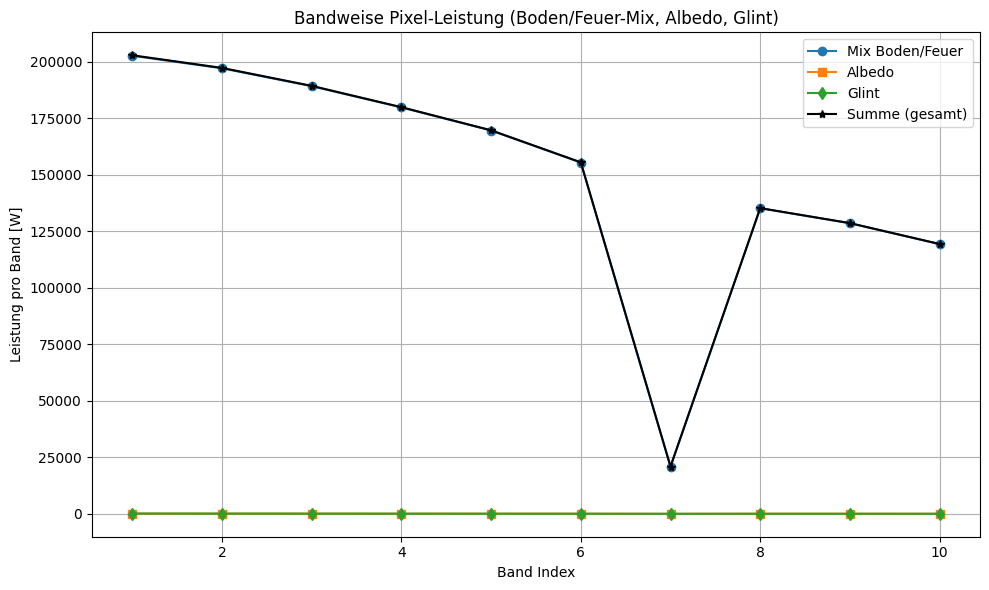

In [10]:
# Plot der Ergebnisse
results = mixed_pixel_power_ground_fire(T_ground=300.0, T_fire=1000.0, delta_fire=0.1, 
                                        band_edges=band_edges, tau_band=tau_mock, area=A_px)
bands = np.arange(1, len(results["P_mix_band"]) + 1)

plt.figure(figsize=(10,6))
plt.plot(bands, results["P_mix_band"], 'o-', label='Mix Boden/Feuer')
plt.plot(bands, results["P_albedo_band"], 's-', label='Albedo')
plt.plot(bands, results["P_glint_band"], 'd-', label='Glint')
plt.plot(bands, results["P_total_band"], 'k*-', label='Summe (gesamt)')
plt.xlabel('Band Index')
plt.ylabel('Leistung pro Band [W]')
plt.title('Bandweise Pixel-Leistung (Boden/Feuer-Mix, Albedo, Glint)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Zusammenhang NETD → NEP

- **NETD** (K) ist die äquivalente Temperatur-Änderung am Szenenobjekt.  
- **NEP** (W/√Hz) ist die äquivalente Leistungs-Änderung am **Detektor**.  

Die Verknüpfung geht über die Kette *Szene → Radiance → Optik → Detektor*:

$$\text{NEP} \;\approx\; 
\underbrace{\frac{\mathrm d P_\text{det}}{\mathrm d T}}_{\text{[W/K] am Arbeitspunkt }T_0}
\cdot \text{NETD}
$$

mit

$$\frac{\mathrm d P_\text{det}}{\mathrm d T} \;=\;
A_\text{det}\;\tau_\text{opt}\;\frac{\pi}{4\,F\#^2}
\int_{\lambda_1}^{\lambda_2} 
\underbrace{\frac{\partial B(\lambda,T)}{\partial T}}_{\text{Planck-Ableitung}}
\;\underbrace{\tau_\text{atm}(\lambda)^2}_{\text{Hin- und Rückweg}}
\;\mathrm d\lambda
$$

- $B(\lambda,T)$: Planck-Radiance  
- $\tau_\text{atm}(\lambda)$: atmosphärische Transmission  
- $\tau_\text{opt}$: optische Transmission der Kamera  
- $F\#$:$Blendenzahl des Systems  
- $A_\text{det}$: aktive Detektorfläche pro Pixel  

> **Hinweis zu √Hz:**  
> NETD ist meist für eine feste Integrationszeit $t_\text{int}$ angegeben.  
> Wenn du **NEP pro √Hz** brauchst, normiere mit dem äquivalenten Rausch-Bandbreitenfaktor deines Filters/Integrators.  
> $\text{NEP}_{\sqrt{\text{Hz}}} \;\approx\; \text{NEP}_\text{gemessen} \cdot \sqrt{t_\text{int}}$
> (Genau hängt es vom Signalpfad/Filter ab.)


Die Grundidee kommt aus den Definitionen der beiden Größen:

- **NETD** ist definiert als die kleinste Temperaturänderung ΔT, die ein System noch als Signal von seinem Rauschen unterscheiden kann.  
  → also:  
  $$ΔS(T) = (dS/dT) · ΔT ≈ Rauschen$$  
  mit S = Sensorsignal (z. B. Spannung oder Leistung am Detektor).

- **NEP** ist definiert als die Strahlungsleistung am Detektor, die gerade dem Rauschen entspricht.  
  → also:  
 $$ NEP = ΔP_\mathrm{det,\,noise}$$

Kombiniert man beide Definitionen, kommt man automatisch auf:

> $$\text{NEP} ≈ (\frac{dP_{det}}{dT}) · \text{NETD}$$

Das ist also eigentlich nur die Kettenregel:  
Temperaturänderung in der Szene → ändert die Strahldichte nach Planck → durch Optik/Atmosphäre auf den Detektor → ergibt eine äquivalente Leistung.

Die Form mit A<sub>det</sub>, F#, τ<sub>opt</sub>, τ<sub>atm</sub> ist dann die „optische Etendue-Formel“ aus der klassischen Infrarot-Sensorik (z. B. siehe H. Budzier & G. Gerlach, *Thermal Infrared Sensors: Theory, Optimisation and Practice*, Wiley 2011 oder Harrison & Lihong, *Infrared Detectors and Systems*, 1996). Dort wird die Leistung auf dem Detektor so berechnet:

$$
P_\text{det}(T) = A_\text{det} \; \tau_\text{opt} \; \frac{\pi}{4 F\#^2} \int_{\lambda_1}^{\lambda_2} B(\lambda, T) \; \tau_\text{atm}(\lambda)^2 \; d\lambda
$$

Wenn man davon die Ableitung nach $T$ bildet und mit $\mathrm{NETD}$ multipliziert, hat man die Näherungsgleichung für NEP.

In unserem Fall lässt sich die Gleichung wie folgt anpassen:
$$
P_\text{det}(T) = A_\text{det} \; \tau_\text{opt} \; \frac{\pi}{4 F\#^2} \sum_{n=1}^{N} \tau_n \cdot \int_{\lambda_{n}}^{\lambda_{n+1}} B(\lambda, T)  \; d\lambda
$$
damit is $\frac{dP_{det}}{dT}$:
$$
\frac{dP_{det}}{dT}= \frac{\partial P_{det}}{\partial T}= A_\text{det} \; \tau_\text{opt} \; \frac{\pi}{4 F\#^2} \sum_{n=1}^{N} \tau_n \cdot \int_{\lambda_{n}}^{\lambda_{n+1}} \frac{\partial B(\lambda, T)}{\partial T}  \; d\lambda
$$

Die Ableitung von Plancks Gesetz $B(\lambda, T)$ nach der Temperatur $T$ ergibt:

$$
\frac{\partial B(\lambda, T)}{\partial T} =
\frac{2 h c^2}{\lambda^5} \cdot
\frac{\exp\left(\frac{h c}{\lambda k T}\right) \cdot \frac{h c}{\lambda k T^2}}
{\left[\exp\left(\frac{h c}{\lambda k T}\right) - 1\right]^2}
$$



In [11]:
def planck_lambda(lmbd, T):
    # B(λ,T) [W / (m^3 sr)]
    return (2 * h * c**2 / lmbd**5) / (np.exp((h*c)/(lmbd*k*T)) - 1)

def dplanck_dT(lmbd, T):
    # ∂B/∂T analytisch (ableiten der Exponentialform)
    x = (h*c)/(lmbd*k*T)
    expx = np.exp(x)
    # d/dT [ 1/(e^x -1) ] = -(e^x * dx/dT)/(e^x -1)^2
    dx_dT = -(h*c)/(lmbd*k*T**2)
    pref = 2*h*c**2 / lmbd**5
    return pref * ( -(expx * dx_dT) / (expx - 1)**2 )

def dPdet_dT(
    T0,                       # Arbeitspunkt [K]
    lambdas,                  # feine λ-Achse [m]
    tau_atm_lambda,           # τ_atm(λ) (gleiche Länge wie lambdas)
    A_det,                    # Detektorfläche pro Pixel [m^2]
    F_number,                 # F#
    tau_opt=0.9,               # optische Transmission (skalar oder spektral passend zu lambdas) --- IGNORE ---
    theta_ap=12  # Aperturwinkel [rad] (optional, Standard 12°)
):
    # Verwende generic_band_power für die Ableitung
    # Integration über das Band
    # Da lambdas und tau_atm_lambda Arrays sind, nehmen wir sie als "Band"
    # Der Faktor ist pi/(4*F_number**2)
    # tau_opt kann skalar oder array sein, wird als Faktor multipliziert
    factor = pi / (4 * F_number**2) * tau_opt
    # generic_band_power erwartet Bandkanten und Transmission pro Band
    # Wir machen ein "Band" von lambdas[0] bis lambdas[-1]

    # Berechne die bandintegrierte Ableitung
    powers, total = generic_band_power(band_edges=lambdas,
                                       tau_band=tau_atm_lambda, 
                                       area=A_det,
                                       theta_ap=np.deg2rad(theta_ap),  # Beispiel-Aperturwinkel
                                       spectral_func=dplanck_dT, spectral_args=(T0,),
                                       factor=factor
    )
    return powers, total  # [W/K]

def netd_to_nep(
    NETD,                     # [K]
    T0, lambdas, tau_atm_lambda,
    A_det, F_number, tau_opt=0.9, theta_ap=12  # Aperturwinkel [rad] (optional, Standard 12°)
):
    _, dP_dT = dPdet_dT(T0, lambdas, tau_atm_lambda, A_det, F_number, tau_opt,theta_ap)
    NEP = dP_dT * NETD        # [W] (für die angegebene Integrationszeit)
    return NEP, dP_dT

## Import MODTRAN Simulation DATA for Atmosphere

In [12]:
import pandas as pd

def get_modtran_data(file_path):
    """
    Load MODTRAN simulation data from a CSV file.
    
    Parameters:
    - file_path: Path to the CSV file containing MODTRAN data.
    
    Returns:
    - DataFrame with columns 'Wavelength' and 'Transmission'.
    """
    df = pd.read_csv(file_path, header=4)
    df.set_index('Freq', inplace=True)
    df = df.iloc[1:-1]
    df.index = 1e-2 / df.index.astype(float)
    df.index.name = 'Wavelength [m]'
    df.columns = df.columns.str.strip()
    df['combin'] = pd.to_numeric(df['combin'], errors='coerce')
    tau = df['combin'].values
    wavelength = df.index.values
    sort_idx = np.argsort(wavelength)
    wavelength = wavelength[sort_idx]
    tau = tau[sort_idx]
    return wavelength, tau, df


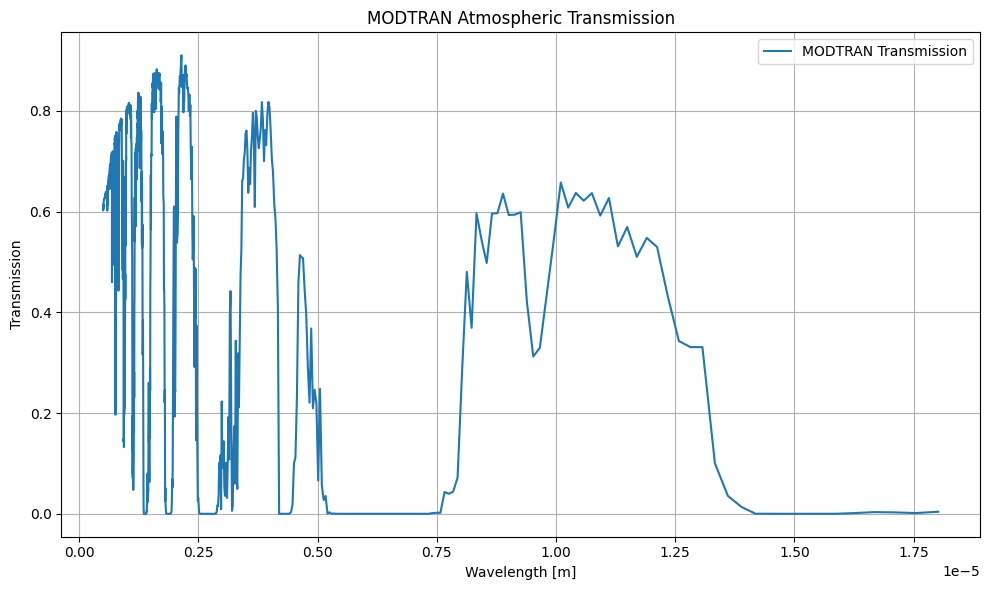

In [13]:
wavelength, transmittance, _ =  get_modtran_data('./atmos_data/AngstromLaw2.csv')
plt.figure(figsize=(10, 6))
plt.plot(wavelength, transmittance, label='MODTRAN Transmission', color='tab:blue')
plt.xlabel('Wavelength [m]')
plt.ylabel('Transmission')
plt.title('MODTRAN Atmospheric Transmission')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Validate Simulation Results 

We compare our model to the results from Lucas Krempel's master thesis.

For this, we plot the power difference of one pixel over the fire area.

**Parameters used:**

- **Detector efficiency:** $\alpha_\mathrm{det} = 0.8$
- **Optical transmission:** $\tau_\mathrm{opt} = 0.5$
- **Soil temperature:** $T_\mathrm{soil} = 300\,\mathrm{K}$
- **Solar temperature:** $T_\mathrm{sun} = 5777\,\mathrm{K}$
- **Aperture diameter:** $D = 6\,\mathrm{cm}$
- **Wavelength range MWIR:** $3\,\mu\mathrm{m}$ – $5\,\mu\mathrm{m}$
- **Wavelength range LWIR:** $8\,\mu\mathrm{m}$ – $12\,\mu\mathrm{m}$
- **Ground sampling distance (GSD):** $200\,\mathrm{m}$
- **Distance to ground:** $d = 600\,\mathrm{km}$
- **Albedo:** $\rho_\mathrm{albedo} = 0.03$
- **Glint:** $0$
- **Aperture half-angle:** $\theta_\mathrm{ap} = 0.5 \cdot D / d$

These parameters are used for validating the simulation results against reference data.

C:\Users\azmib\AppData\Local\Temp\ipykernel_21000\1394235320.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_band = np.trapz(spectral, wavelengths)  # [W/(m^2 sr)]


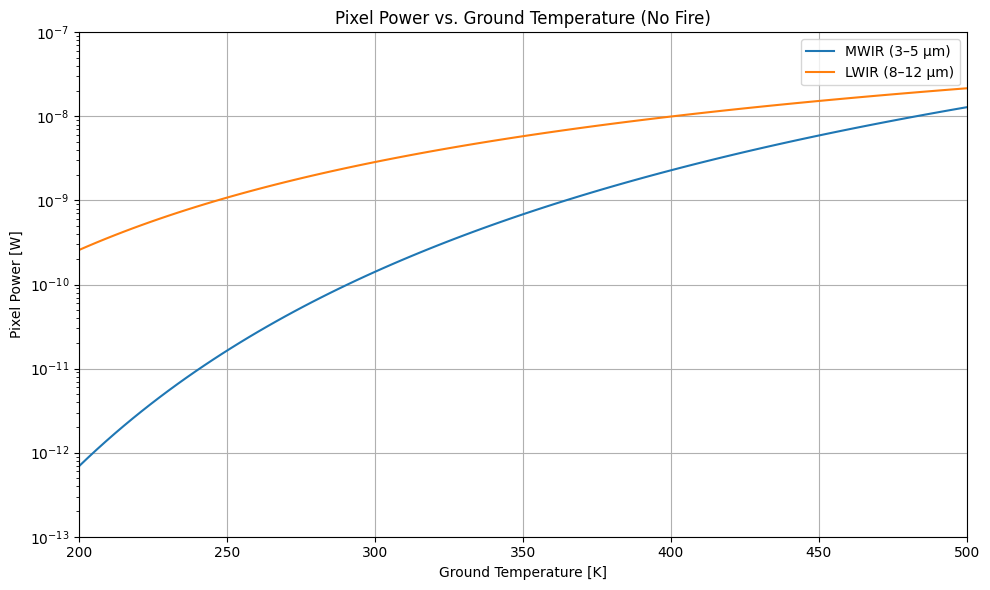

In [14]:
# Plot pixel power vs. ground temperature for MWIR and LWIR bands (no fire)
# Parameters
GSD = 200 # Ground Sample Distance [m]
A_px = GSD**2
D = 0.06  # Aperture diameter [m]
d = 600e3  # Distance to ground [m]
tau_opt = 0.5  # Optical transmission
alpha_det = 0.8  # Detector efficiency
#theta_ap = np.arctan(D / (2 * d))  # Aperture half-angle in radians
theta_ap = 0.5 * D / d  # Alternative calculation for half-angle

wavelength, transmittance, _ =  get_modtran_data('./atmos_data/AngstromLaw2.csv')
# MWIR: 3–5 µm
mw_band_edges = wavelength[(wavelength >= 3e-6) & (wavelength <= 5e-6)]
mw_tau = transmittance  # assume perfect transmission for demonstration

# LWIR: 8–12 µm
lw_band_edges = wavelength[(wavelength >= 8e-6) & (wavelength <= 12e-6)]
lw_tau = transmittance  # assume perfect transmission for demonstration

T_range = np.linspace(200, 500, 100)  # ground temperature range [K]
mw_power = []
lw_power = []

for T in T_range:
    # MWIR
    P_mw_band, P_mw_total = generic_band_power(
        mw_band_edges, mw_tau, A_px, theta_ap=theta_ap,
        spectral_func=planck_lambda, spectral_args=(T,),
        factor=tau_opt * alpha_det,
        single_transmission=True
    )
    mw_power.append(P_mw_total)
    # LWIR
    P_lw_band, P_lw_total = generic_band_power(
        lw_band_edges, lw_tau, A_px, theta_ap=theta_ap,
        spectral_func=planck_lambda, spectral_args=(T,),
        factor=tau_opt * alpha_det,
        single_transmission=True
    )
    lw_power.append(P_lw_total)

fig1 = plt.figure(figsize=(10, 6))

plt.plot(T_range, mw_power, label='MWIR (3–5 µm)')
plt.plot(T_range, lw_power, label='LWIR (8–12 µm)')
plt.yscale('log')  # Logarithmic scale for better visibility
plt.xlim(200, 500)
plt.ylim(1e-13, 1e-7)  # Adjust y-axis limits for better visibility
plt.xlabel('Ground Temperature [K]')
plt.ylabel('Pixel Power [W]')
plt.title('Pixel Power vs. Ground Temperature (No Fire)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Boson Teledyne: Optische und Detektor-Parameter

| Parameter            | Wert / Optionen         | Beschreibung                       |
|----------------------|------------------------|------------------------------------|
| **Wellenlängenbereich** | 8–14 µm                | LWIR-Spektralbereich               |
| **NETD**             | 40 mK, 50 mK, 60 mK     | Detektor-Rauschgrenze              |
| **FOV**              | 6° (36 mm) <br> 12° (18 mm) | Sichtfeld / Optik-Variante         |
| **Pixel Pitch**      | 12 µm                   | Detektor-Pixelgröße                |
| **Optische Transmission** | τ<sub>opt</sub> = 0.9 | Transmission der Optik             |

---

#### Wichtige Variablen im Notebook

| Name         | Wert                | Einheit / Bedeutung                |
|--------------|---------------------|------------------------------------|
| **A_det**    | 2.89 × 10⁻¹⁰        | m², Detektorfläche pro Pixel       |
| **A_px**     | 40 000              | m², Pixel-Fläche auf Erde          |
| **D**        | 0.06                | m, Apertur-Durchmesser             |
| **Fno**      | 2.0                 | Blendenzahl (F#)                   |
| **GSD**      | 200                 | m, Ground Sampling Distance        |
| **tau_opt**  | 0.9                 | Optische Transmission              |
| **alpha_det**| 0.8                 | Detektor-Effizienz                 |
| **theta_ap** | 5 × 10⁻⁸            | rad, Apertur-Halbwinkel            |
| **T_ground** | 300.0               | K, Bodentemperatur                 |
| **T_sun**    | 5777.0              | K, Sonnen-Temperatur               |
| **NETD**     | 0.04                | K, Noise Equivalent Temperature Diff|
| **NEP**      | 8.24 × 10⁻¹⁴        | W, Noise Equivalent Power          |

---

#### Beispiel-Ergebnisse

- **Boden-Emission (MWIR, Summe):**  
    P<sub>ground_total</sub> = 1.35 × 10⁻⁹ W

- **Albedo (MWIR, Summe):**  
    P<sub>albedo_total</sub> = 1.24 × 10⁻¹⁰ W

- **Glint (MWIR, Summe):**  
    P<sub>glint_total</sub> = 0 W

- **Pixel-Gesamtleistung:**  
    P<sub>total</sub> = 5.91 × 10⁻¹⁰ W

---

**Hinweis:**  
Alle Werte und Variablen sind direkt im Notebook verfügbar und können für weitere Berechnungen und Visualisierungen genutzt werden.

In [15]:
# Gegebene NETD-Werte (in Kelvin)
netd_values = [0.04, 0.05, 0.06]
# Wellenlange des Sensors (8-12 µm)
sensor_mask = (wavelength >= 8e-6) & (wavelength <= 12e-6)
sensor_wavelength = wavelength[sensor_mask]
sensor_transmittance = transmittance[sensor_mask]

A_det = (12e-6)**2 # Detektorfläche pro Pixel [m^2]
Fno = 0.06 / 0.018
tau_opt = 0.8  # Optische Transmission
# Berechne NEP für jeden NETD-Wert
nep_results = {}
T = np.linspace(200, 500, 100)  # Temperaturbereich für NEP-Berechnung
for netd in netd_values:
    nep = []
    for T0 in T:
        nep_single, dP_dT_val = netd_to_nep(
            NETD=netd,
            T0=T0,
            lambdas=sensor_wavelength, # hier nur die Wellenlänge des Sensors
            tau_atm_lambda=sensor_transmittance,
            A_det=A_det,
            F_number=Fno,
            tau_opt=tau_opt,
            theta_ap=12  # Beispiel-Aperturwinkel
        )
        nep.append(nep_single)
    nep_results[netd] = nep
# Ausgabe
for netd, nep in nep_results.items():
    print(f"NETD = {netd:.3f} K → NEP (mean) = {np.mean(nep):.3e} W")

C:\Users\azmib\AppData\Local\Temp\ipykernel_21000\1394235320.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I_band = np.trapz(spectral, wavelengths)  # [W/(m^2 sr)]


NETD = 0.040 K → NEP (mean) = 1.220e-14 W
NETD = 0.050 K → NEP (mean) = 1.524e-14 W
NETD = 0.060 K → NEP (mean) = 1.829e-14 W


fig1

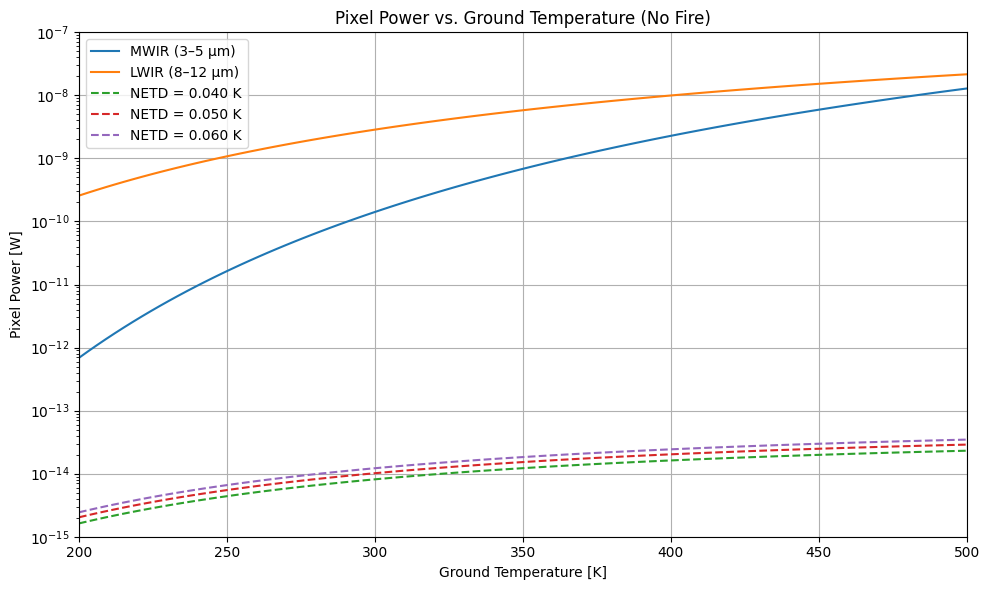

In [16]:
# Plot der NEP-Ergebnisse
plt.figure(figsize=(10, 6))
plt.plot(T_range, mw_power, label='MWIR (3–5 µm)')
plt.plot(T_range, lw_power, label='LWIR (8–12 µm)')
for netd, nep in nep_results.items():
    plt.plot(T_range, nep, label=f'NETD = {netd:.3f} K', linestyle='--')
plt.yscale('log')  # Logarithmic scale for better visibility
plt.xlim(200, 500)
plt.ylim(1e-15, 1e-7)  # Adjust y-axis limits for better visibility
plt.xlabel('Ground Temperature [K]')
plt.ylabel('Pixel Power [W]')
plt.title('Pixel Power vs. Ground Temperature (No Fire)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()